## 1. Kurulum ve Bağımlılıklar

## ⚙️ Konfigürasyon — Sadece bu hücreyi değiştir!
Farklı bir branch veya dataset için **yalnızca aşağıdaki hücreyi** güncelle. Geri kalan tüm hücreler buradan okur.


In [ ]:
# ============================================================
# PROJE KONFİGÜRASYONU — Branch değiştirince sadece burayı güncelle
# ============================================================

# --- GitHub & Drive ---
REPO_URL        = "https://github.com/panzerofthelake03/DiffuVQA.git"
BRANCH          = "Bert"
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/DiffuVQA"
LOCAL_CLONE_PATH   = "/content/DiffuVQA"

# --- Model ---
MODEL_NAME      = "bert"         # "bert" veya "pubmedbert"
MODEL_LABEL     = "DiffuVQA-Bert"

# --- Dataset ---
DATASET         = "SLAKE"             # "SLAKE", "Kvasir_VQA", "daveKevin" vb.
DATA_DIR        = "datasets"
DRIVE_IMAGE_DIR = f"{DRIVE_PROJECT_PATH}/datasets/imgs"
LOCAL_IMAGE_DIR = f"{LOCAL_CLONE_PATH}/datasets"

# Drive'daki dataset görüntü klasörü (birden fazla olası yol)
DATASET_IMG_PATHS = [
    f"/content/drive/MyDrive/datasets/{DATASET}/imgs/imgs",
    f"/content/drive/MyDrive/{DATASET}_dataset/imgs",
    f"/content/drive/Drive'ım/{DATASET}_dataset/imgs",
    f"/content/drive/MyDrive/{DATASET}/imgs",
    f"/content/drive/Drive'ım/{DATASET}/imgs",
]

# --- Eğitim ---
BATCH_SIZE      = 64
LR              = 0.000283
LEARNING_STEPS  = 150000
DIFFUSION_STEPS = 2000
SEQ_LEN         = 64
HIDDEN_T_DIM    = 768
SEED            = 42
SAVE_INTERVAL   = 5000
SAMPLE_STEP     = 200          # DDIM: 2000 adımı ~10x hızlandırır
MICROBATCH      = 16           # gradient accumulation: 64/16 = 4 microbatch
LOG_INTERVAL    = 100

# --- Checkpoint & Çıktı ---
CHECKPOINT_PATH = f"./checkpoints/{DATASET.lower()}_{MODEL_NAME.lower()}"
RESUME_CHECKPOINT = ""          # Boş bırakırsan sıfırdan başlar. Örnek: "checkpoints/slake_bert/ema_0.9999_050000.pt"
SAMPLE_FOLDER   = "./samples/"
OUTPUT_CSV      = f"./reports/{MODEL_NAME}_{DATASET.lower()}_evaluation_results.csv"
DRIVE_RESULTS_PATH = "/content/drive/MyDrive/DiffuVQA_Results/"

print("✅ Konfigürasyon yüklendi:")
print(f"   Branch    : {BRANCH}  →  {REPO_URL}")
print(f"   Model     : {MODEL_NAME}")
print(f"   Dataset   : {DATASET}")
print(f"   Checkpoint: {CHECKPOINT_PATH}")


✅ Konfigürasyon yüklendi:
   Branch    : Bert  →  https://github.com/panzerofthelake03/DiffuVQA.git
   Model     : Bert
   Dataset   : SLAKE
   Checkpoint: ./checkpoints/slake_bert


In [ ]:
# GPU kontrolü
!nvidia-smi

Fri Mar  6 14:49:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import shutil

# ADIM 1: Colab'daki geçici klasörü temizle (Taze indirme için şart)
if os.path.exists(LOCAL_CLONE_PATH):
    print(f"Eski geçici klasör siliniyor: {LOCAL_CLONE_PATH}")
    shutil.rmtree(LOCAL_CLONE_PATH)

# ADIM 2: GitHub'dan en güncel hali çek
print("GitHub'dan taze kopya çekiliyor...")
!git clone -b {BRANCH} --single-branch {REPO_URL} {LOCAL_CLONE_PATH}

# ADIM 3: Drive'ı GÜNCELLE (dirs_exist_ok=True ile klasör olsa bile içine girip dosyaları yeniler)
print(f"Drive'daki dosyalar güncelleniyor: {DRIVE_PROJECT_PATH}")
if not os.path.exists(DRIVE_PROJECT_PATH):
    os.makedirs(DRIVE_PROJECT_PATH)

shutil.copytree(LOCAL_CLONE_PATH, DRIVE_PROJECT_PATH, dirs_exist_ok=True)
print("\n✅ İŞLEM TAMAM: Yeni dosyalar Drive'a geçti!")

# Çalışma dizinini Drive'daki projeye ayarla
os.chdir(DRIVE_PROJECT_PATH)
print(f"📂 Çalışma dizini: {os.getcwd()}")


Eski geçici klasör siliniyor: /content/DiffuVQA
GitHub'dan taze kopya çekiliyor...
Cloning into '/content/DiffuVQA'...
remote: Enumerating objects: 819, done.
remote: Counting objects: 100% (277/277), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 819 (delta 223), reused 207 (delta 195), pack-reused 542 (from 2)
Receiving objects: 100% (819/819), 107.03 MiB | 16.07 MiB/s, done.
Resolving deltas: 100% (383/383), done.
Updating files: 100% (424/424), done.
Drive'daki dosyalar güncelleniyor: /content/drive/MyDrive/DiffuVQA

✅ İŞLEM TAMAM: Yeni dosyalar Drive'a geçti!
📂 Çalışma dizini: /content/drive/MyDrive/DiffuVQA


In [ ]:
# Mevcut bir Drive klonu varsa sadece güncelle (clone yerine alternatif)
if os.path.exists(DRIVE_PROJECT_PATH):
    os.chdir(DRIVE_PROJECT_PATH)
    print(f"📂 Çalışma dizini değiştirildi: {os.getcwd()}")
    print("⬇️ GitHub'dan güncellemeler çekiliyor (git pull)...")
    !git pull
    print("\n✅ Güncelleme tamamlandı. İşte son 3 değişiklik:")
    !git log -3 --oneline
else:
    print("❌ Hata: Drive'da proje klasörü bulunamadı. Önce yukarıdaki clone hücresini çalıştır.")


📂 Çalışma dizini değiştirildi: /content/drive/MyDrive/DiffuVQA
⬇️ GitHub'dan güncellemeler çekiliyor (git pull)...
Already up to date.

✅ Güncelleme tamamlandı. İşte son 3 değişiklik:
71821f1 (HEAD -> Bert, origin/Bert) debug purpose update on vqa datasets
5eb8921 Update vqa_datasets.py
d50d579 Delete run_diffuvqa_colab.ipynb


In [ ]:
import os
import shutil
from tqdm.auto import tqdm


# Assuming the SLAKE image data is located at a specific path on Google Drive.
# IMPORTANT: PLEASE UPDATE 'source_slake_image_path' WITH THE ACTUAL PATH TO YOUR SLAKE IMAGES.
# Example: '/content/drive/MyDrive/SLAKE_DATA/imgs' or '/content/drive/MyDrive/datasets/slake/imgs'
source_slake_image_path = f"{DRIVE_PROJECT_PATH}/datasets/{DATASET}/imgs" # <--- UPDATE THIS PATH!

# 'drive_project_path' and 'data_set' variables are already defined in previous cells.

if DATASET.lower() == 'slake':
    destination_slake_image_path = os.path.join(LOCAL_CLONE_PATH, 'datasets')

    print(f"Checking if source SLAKE image path exists: {source_slake_image_path}")
    if os.path.exists(source_slake_image_path):
        os.makedirs(destination_slake_image_path, exist_ok=True)
        print(f"Copying SLAKE images from '{source_slake_image_path}' to '{destination_slake_image_path}'...")

        # Build a file list first so tqdm can show total progress.
        files_to_copy = []
        for root, _, files in os.walk(source_slake_image_path):
            for file_name in files:
                src_file = os.path.join(root, file_name)
                rel_path = os.path.relpath(src_file, source_slake_image_path)
                dst_file = os.path.join(destination_slake_image_path, rel_path)
                files_to_copy.append((src_file, dst_file))

        for src_file, dst_file in tqdm(files_to_copy, desc="Copying SLAKE files", unit="file"):
            os.makedirs(os.path.dirname(dst_file), exist_ok=True)
            shutil.copy2(src_file, dst_file)

        print("✅ SLAKE images copied successfully!")
    else:
        print(f"❌ Error: Source SLAKE image path not found: '{source_slake_image_path}'. Please update the 'source_slake_image_path' variable in this cell.")
else:
    print(f"Dataset is '{DATASET}', no SLAKE-specific image copying needed.")


Checking if source SLAKE image path exists: /content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs
Copying SLAKE images from '/content/drive/MyDrive/DiffuVQA/datasets/SLAKE/imgs' to '/content/DiffuVQA/datasets'...


Copying SLAKE files:   0%|          | 0/2592 [00:00<?, ?file/s]

✅ SLAKE images copied successfully!


In [ ]:
# Dataset yapısını kontrol et
!echo "📂 Dataset klasörü:"
!ls -lh datasets/
!echo "\n📊 JSONL dosyaları:"
!ls -lh datasets/*.jsonl
!echo "\n🖼️ Image klasörü (symlink):"
!ls -lh datasets/imgs/ | head -5
!echo "\n📄 Train set örneği:"
!head -n 1 datasets/train.jsonl



📂 Dataset klasörü:
total 2.6M
drwx------ 2 root root 4.0K Dec 17 20:24 daveKevin_images
-rw------- 1 root root 132K Mar  2 10:01 daveKevin_samples_test.png
-rw------- 1 root root 158K Mar  2 14:18 daveKevin_samples_train.png
-rw------- 1 root root 179K Mar  2 14:19 daveKevin_samples_valid.png
drwx------ 3 root root 4.0K Mar  5 10:12 SLAKE
-rw------- 1 root root  17K Mar  6 14:47 SLAKE_test_first3_preview.png
-rw------- 1 root root  16K Mar  6 14:23 SLAKE_train_first3_preview.png
-rw------- 1 root root  16K Mar  6 14:23 SLAKE_valid_first3_preview.png
-rw------- 1 root root 324K Mar  6 14:49 test.jsonl
-rw------- 1 root root 1.5M Mar  6 14:49 train.jsonl
-rw------- 1 root root 322K Mar  6 14:49 valid.jsonl
\n📊 JSONL dosyaları:
-rw------- 1 root root 324K Mar  6 14:49 datasets/test.jsonl
-rw------- 1 root root 1.5M Mar  6 14:49 datasets/train.jsonl
-rw------- 1 root root 322K Mar  6 14:49 datasets/valid.jsonl
\n🖼️ Image klasörü (symlink):
ls: cannot access 'datasets/imgs/': No such file o

Searching for images in: /content/DiffuVQA/datasets/imgs
Found 1284 images.


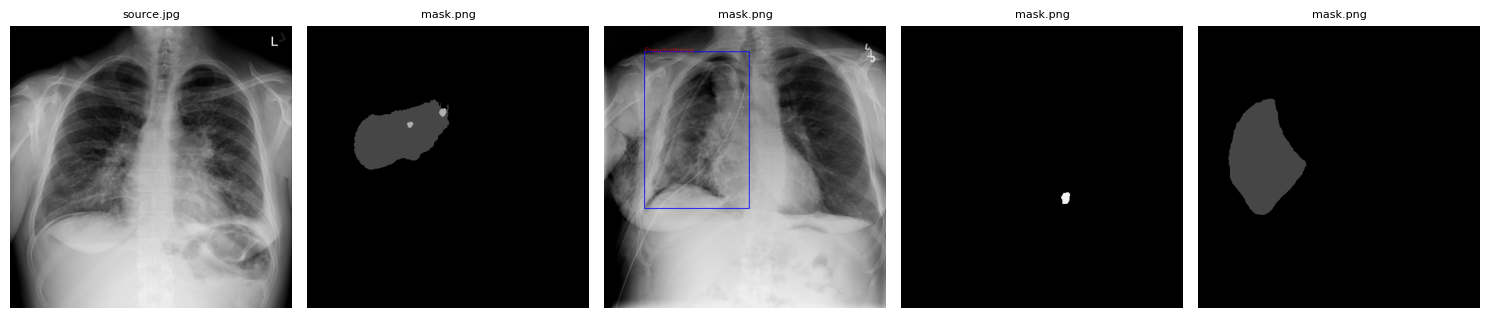

✅ Displayed 5 example images.


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# Construct the full image directory path
# Assuming images are in a subdirectory 'imgs' within destination_slake_image_path
image_folder_path = os.path.join(destination_slake_image_path, 'imgs')

print(f"Searching for images in: {image_folder_path}")

# Get a list of all image files (assuming common image extensions)
image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')
all_image_files = []
for root, _, files in os.walk(image_folder_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            all_image_files.append(os.path.join(root, file))

if not all_image_files:
    print(f"⚠️ No images found in {image_folder_path}. Please check the path and content.")
else:
    print(f"Found {len(all_image_files)} images.")
    # Select a few random images to display
    num_examples = min(5, len(all_image_files))
    selected_images = random.sample(all_image_files, num_examples)

    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(selected_images):
        try:
            img = Image.open(img_path)
            plt.subplot(1, num_examples, i + 1)
            plt.imshow(img)
            plt.title(os.path.basename(img_path), fontsize=8)
            plt.axis('off')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            plt.subplot(1, num_examples, i + 1)
            plt.text(0.5, 0.5, 'Error', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, color='red')
            plt.axis('off')

    plt.tight_layout()
    plt.show()
    print(f"✅ Displayed {num_examples} example images.")


In [ ]:
# vqa_datasets __main__ test (runs the module exactly like a script)
import os
import sys
import subprocess

# Ensure we run from project root
os.chdir(DRIVE_PROJECT_PATH)
print(f"cwd: {os.getcwd()}")

# Use the same dataset paths used by training notebook
data_dir = DATA_DIR
image_dir = destination_slake_image_path
dataset_name = DATASET

cmd = [
    sys.executable,
    "-m",
    "diffuvqa.vqa_datasets",
    "--data_dir", data_dir,
    "--dataset", dataset_name,
    "--image_dir", image_dir,
    "--vocab", MODEL_NAME.lower(),
    "--config_name", "bert-base-uncased" if MODEL_NAME.lower() == "bert" else MODEL_NAME,
    "--batch_size", "1",
    "--seq_len", "64",
    "--image_size", "224",
]

print("Running command:")
print(" ".join(cmd))
print("-" * 80)

# Capture output so preview/path logs from vqa_datasets are visible in this cell
result = subprocess.run(cmd, text=True, capture_output=True)
print(result.stdout)
if result.stderr:
    print("[stderr]")
    print(result.stderr)

print("-" * 80)
print(f"Return code: {result.returncode}")
if result.returncode != 0:
    print("vqa_datasets __main__ test failed. Check logs above for missing path/dependency details.")
else:
    print("vqa_datasets __main__ test completed successfully.")

cwd: /content/drive/MyDrive/DiffuVQA
Running command:
/usr/bin/python3 -m diffuvqa.vqa_datasets --data_dir datasets --dataset SLAKE --image_dir /content/DiffuVQA/datasets --vocab bert --config_name bert-base-uncased --batch_size 1 --seq_len 64 --image_size 224
--------------------------------------------------------------------------------
save tokenizer to diffuvqa/config
reload the random embeddings Embedding(30522, 1024)
Logging to /tmp/openai-2026-03-06-15-58-41-474448
##############################
Loading text data...
##############################
Loading dataset SLAKE from datasets...
### Loading from the TRAIN set...
### Data samples...
questions: ['What modality is used to take this image?', 'Which part of the body does this image belong to?'] answers: ['MRI', 'Abdomen'] images: ['imgs/xmlab1/source.jpg', 'imgs/xmlab1/source.jpg']
Attempted image path: /content/DiffuVQA/datasets/imgs/xmlab1/source.jpg
Parent folder of attempted image path: /content/DiffuVQA/datasets/imgs/xmla

In [ ]:
# Bağımlılıkları yükle
# Colab PyTorch ile geliyor, o yüzden requirements_colab.txt kullanıyoruz
!pip install --upgrade pip
!pip install -r requirements_colab.txt
!pip install pandas openpyxl bert-score  # Excel support ve BERTScore için
!python -m spacy download en_core_web_sm

print("\n✅ Kurulum tamamlandı!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 44.2 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

✅ Kurulum tamamlandı!


In [ ]:
# Gerekli kütüphaneleri içe aktar
import os
import sys
import json
import torch
import pandas as pd
import numpy as np
from datetime import datetime
from collections import defaultdict
import glob

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla T4


## 2. Model Eğitimi (BERT)

In [ ]:
import os
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

!python train.py \
    --vocab {MODEL_NAME.lower()} \
    --use_plm_init {MODEL_NAME} \
    --batch_size {BATCH_SIZE} \
    --lr {LR} \
    --diffusion_steps {DIFFUSION_STEPS} \
    --seq_len {SEQ_LEN} \
    --hidden_t_dim {HIDDEN_T_DIM} \
    --checkpoint_path {CHECKPOINT_PATH} \
    --seed {SEED} \
    --learning_steps {LEARNING_STEPS} \
    --save_interval {SAVE_INTERVAL} \
    --log_interval {LOG_INTERVAL} \
    --data_dir {DATA_DIR} \
    --dataset {DATASET} \
    --image_dir {destination_slake_image_path} \
    --microbatch {MICROBATCH} \
    --resume_checkpoint {RESUME_CHECKPOINT if RESUME_CHECKPOINT else "none"}


Logging to /tmp/openai-2026-03-06-15-59-39-878468
### Creating data loader...
save tokenizer to ./checkpoints/slake_bert
reload the random embeddings Embedding(30522, 768)
##############################
Loading text data...
##############################
Loading dataset SLAKE from datasets...
### Loading from the TRAIN set...
### Data samples...
questions: ['What modality is used to take this image?', 'Which part of the body does this image belong to?'] answers: ['MRI', 'Abdomen'] images: ['imgs/xmlab1/source.jpg', 'imgs/xmlab1/source.jpg']
Attempted image path: /content/DiffuVQA/datasets/imgs/xmlab1/source.jpg
Parent folder of attempted image path: /content/DiffuVQA/datasets/imgs/xmlab1
Inside parent folder (/content/DiffuVQA/datasets/imgs/xmlab1): ['mask.png', 'source.jpg', 'detection.json', 'question.json']
### Loading image for preview: /content/DiffuVQA/datasets/imgs/xmlab1/source.jpg
Attempted image path: /content/DiffuVQA/datasets/imgs/xmlab1/source.jpg
Parent folder of attempte

### 2b. Kaldığı Yerden Devam (Resume)
Eğitim kesintiye uğradıysa aşağıdaki hücreyi çalıştır. `RESUME_CHECKPOINT` değişkenini config hücresinde doldurmayı unutma.

In [ ]:
# Kaldığı yerden devam — RESUME_CHECKPOINT config hücresinde tanımlı olmalı
import glob, os

if not RESUME_CHECKPOINT:
    # En son kaydedilen EMA checkpoint'i otomatik bul
    ema_files = sorted(glob.glob(f"{CHECKPOINT_PATH}/ema_0.9999_*.pt"))
    if ema_files:
        RESUME_CHECKPOINT = ema_files[-1]
        print(f"✅ Resume checkpoint otomatik bulundu: {RESUME_CHECKPOINT}")
    else:
        print("⚠️  Checkpoint bulunamadı — sıfırdan başlayacak.")

os.makedirs(CHECKPOINT_PATH, exist_ok=True)

!python train.py \
    --vocab {MODEL_NAME.lower()} \
    --use_plm_init {MODEL_NAME} \
    --batch_size {BATCH_SIZE} \
    --lr {LR} \
    --diffusion_steps {DIFFUSION_STEPS} \
    --seq_len {SEQ_LEN} \
    --hidden_t_dim {HIDDEN_T_DIM} \
    --checkpoint_path {CHECKPOINT_PATH} \
    --seed {SEED} \
    --learning_steps {LEARNING_STEPS} \
    --save_interval {SAVE_INTERVAL} \
    --log_interval {LOG_INTERVAL} \
    --data_dir {DATA_DIR} \
    --dataset {DATASET} \
    --image_dir {destination_slake_image_path} \
    --microbatch {MICROBATCH} \
    --resume_checkpoint {RESUME_CHECKPOINT}


## 3. Model Örnekleme (Inference)

In [ ]:
# Test seti üzerinde örnekleme yap
# Checkpoint dosyasını otomatik bul
checkpoint_files = sorted(glob.glob(f"{CHECKPOINT_PATH}/ema_*.pt"))

if checkpoint_files:
    checkpoint_file = checkpoint_files[-1]
    print(f"📂 Kullanılacak checkpoint: {checkpoint_file}")
else:
    print("⚠️ Checkpoint bulunamadı! Lütfen önce eğitimi tamamlayın.")
    checkpoint_file = None

if checkpoint_file:
    !python sample_vqa_GPU.py \
        --model_path {checkpoint_file} \
        --step 50 \
        --batch_size {BATCH_SIZE} \
        --seed2 105 \
        --split test \
        --clamp_step 0

    print(f"\n✅ Örnekleme tamamlandı!")
    print(f"📂 Çıktı dosyaları {SAMPLE_FOLDER} klasöründe oluşturuldu.")
    !echo "\n📄 Oluşturulan sample dosyaları:"
    !ls -lh {SAMPLE_FOLDER}*.jsonl | tail -5


📂 Kullanılacak checkpoint: ./checkpoints/slake_bert/ema_0.9999_003800.pt
Logging to /tmp/openai-2026-03-06-14-46-44-067173
DEBUG: Parsed model_path = ./checkpoints/slake_bert/ema_0.9999_003800.pt
### Loading model from ./checkpoints/slake_bert/ema_0.9999_003800.pt
config_path: ./checkpoints/slake_bert/training_args.json
### Updated args: Namespace(model_path='./checkpoints/slake_bert/ema_0.9999_003800.pt', step=50, out_dir='', top_p=0, lr=0.0001, batch_size=2, learning_steps=4000, microbatch=64, log_interval=50, save_interval=200, eval_interval=500, valid=True, ema_rate='0.9999', resume_checkpoint='none', schedule_sampler='lossaware', diffusion_steps=100, noise_schedule='sqrt', timestep_respacing=[100], vocab='bert', use_plm_init='Bert', vocab_size=30522, config_name='bert-base-uncased', notes='folder-notes', data_dir='datasets', dataset='SLAKE', image_dir='/content/drive/MyDrive/DiffuVQA/datasets/imgs', checkpoint_path='./checkpoints/slake_bert', image_encoder='ViT-B/32', image_resolu

In [ ]:
# compare_image_black_vectors.py hızlı test hücresi (dataset-safe + import-safe + error-aware)
import glob
import os
import sys
import subprocess

# Komutu proje kökünden çalıştır ki `diffuvqa` import'u çözülsün
os.chdir(DRIVE_PROJECT_PATH)
print(f"📂 Çalışma dizini: {os.getcwd()}")

checkpoint_files = sorted(glob.glob(f"{CHECKPOINT_PATH}/ema_*.pt"))

if checkpoint_files:
    checkpoint_file = checkpoint_files[-1]
    print(f"📂 Vector karşılaştırma için checkpoint: {checkpoint_file}")
else:
    print("⚠️ Checkpoint bulunamadı. Önce eğitim/örnekleme hücrelerini çalıştır.")
    checkpoint_file = None

if checkpoint_file:
    os.makedirs("./outputs", exist_ok=True)
    out_jsonl = f"./outputs/{MODEL_NAME}_{DATASET.lower()}_real_vs_black_vectors.jsonl"
    out_pt = f"./outputs/{MODEL_NAME}_{DATASET.lower()}_real_vs_black_vectors.pt"

    # Notebook genelindeki dataset/image ayarlarını zorunlu kullan.
    image_dir_arg = destination_slake_image_path if "destination_slake_image_path" in globals() else LOCAL_IMAGE_DIR
    print(f"🧭 compare dataset: {DATASET} | data_dir: {DATA_DIR} | image_dir: {image_dir_arg}")

    cmd = [
        sys.executable,
        "-m", "scripts.compare_image_black_vectors",
        "--model_path", checkpoint_file,
        "--split", "test",
        "--batch_size", str(BATCH_SIZE),
        "--max_samples", "50",
        "--data_dir", DATA_DIR,
        "--dataset", DATASET,
        "--image_dir", image_dir_arg,
        "--out_jsonl", out_jsonl,
        "--out_pt", out_pt,
    ]

    print("🚀 Komut çalıştırılıyor:")
    print(" ".join(cmd))

    result = subprocess.run(cmd, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print("[stderr]")
        print(result.stderr)

    if result.returncode == 0 and os.path.exists(out_jsonl):
        print("\n✅ Vector comparison testi tamamlandı")
        print(f"📄 JSONL: {out_jsonl}")
        print(f"🧠 PT   : {out_pt}")
        print("\n📌 İlk 3 satır:")
        with open(out_jsonl, "r", encoding="utf-8") as f:
            for idx, line in enumerate(f):
                if idx >= 3:
                    break
                print(line.rstrip())
    else:
        print(f"⚠️ Vector comparison başarısız (return code: {result.returncode}).")
        print("Logları kontrol et. Gerekirse PYTHONPATH ayarı ile tekrar deneyebilirsin.")

## 4. Model Değerlendirme ve CSV Export

In [ ]:
# Değerlendirme fonksiyonları
from torchmetrics.text.rouge import ROUGEScore
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk

# NLTK veri setlerini indir
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

rougeScore = ROUGEScore()

def get_bleu(recover, reference, n=1):
    """BLEU-n score"""
    weights = tuple((1.0 / n for _ in range(n)))
    return sentence_bleu([reference.split()], recover.split(),
                        weights=weights,
                        smoothing_function=SmoothingFunction().method4)

def rouge_l_score(prediction, reference):
    """ROUGE-L score"""
    scores = rougeScore(prediction, reference)
    return scores['rougeL_fmeasure'].item()

def calculate_meteor(prediction, reference):
    """METEOR score"""
    return meteor_score([word_tokenize(reference)], word_tokenize(prediction))

def cider_score(predictions, references):
    """CIDEr-like score using TF-IDF cosine similarity"""
    if not predictions or not references:
        return 0.0
    try:
        vectorizer = TfidfVectorizer()
        tfidf_matrix = vectorizer.fit_transform(predictions + references)
        n_pred = len(predictions)
        pred_vectors = tfidf_matrix[:n_pred]
        ref_vectors = tfidf_matrix[n_pred:]
        similarities = cosine_similarity(pred_vectors, ref_vectors)
        return similarities.diagonal().mean()
    except:
        return 0.0

print("✅ Değerlendirme fonksiyonları hazır")


ModuleNotFoundError: No module named 'torchmetrics'

In [ ]:
def evaluate_and_export_csv(sample_files, output_csv="evaluation_results.csv", dataset_file="datasets/test.jsonl",
                            model_label="DiffuVQA", dataset_label="SLAKE"):
    """
    Örneklenmiş model çıktılarını değerlendir ve CSV'ye kaydet

    Args:
        sample_files: JSONL formatında örnek dosyaları (liste veya tek dosya)
        output_csv: Çıktı CSV dosya yolu
        dataset_file: Original dataset (answer_type bilgisi için)
        model_label: Raporda görünecek model ismi
        dataset_label: Raporda görünecek dataset ismi
    """
    if isinstance(sample_files, str):
        sample_files = [sample_files]

    # Dataset'ten answer_type mapping'i oluştur
    print(f"📂 Dataset'ten answer_type bilgisi yükleniyor: {dataset_file}")
    answer_type_map = {}
    try:
        with open(dataset_file, 'r', encoding='utf-8') as f:
            for line in f:
                data = json.loads(line)
                qid = data.get('qid')
                question = data.get('question', '').strip().lower()
                answer_type = data.get('answer_type', 'UNKNOWN')

                if qid:
                    answer_type_map[qid] = answer_type
                if question:
                    answer_type_map[question] = answer_type
        print(f"✅ {len(answer_type_map)} answer_type mapping yüklendi")
    except Exception as e:
        print(f"⚠️ Dataset yüklenemedi: {e}")
        answer_type_map = {}

    all_results = []

    for sample_file in sample_files:
        print(f"\n📊 Değerlendiriliyor: {sample_file}")

        samples = []
        with open(sample_file, 'r', encoding='utf-8') as f:
            for line in f:
                samples.append(json.loads(line))

        print(f"✅ {len(samples)} satır okundu")

        bleu1_scores = []
        rougeL_scores = []
        meteor_scores = []
        f1_scores = []
        predictions = []
        references = []

        total_samples = 0
        correct_all = 0
        correct_yn = 0
        correct_oe = 0
        count_yn = 0
        count_oe = 0
        empty_count = 0

        for sample in samples:
            pred = (sample.get('generate_answer') or
                   sample.get('recover') or
                   sample.get('generated_answer') or
                   sample.get('prediction') or '').strip()

            ref = (sample.get('reference_answer') or
                  sample.get('reference') or
                  sample.get('answer') or '').strip()

            q_type = sample.get('answer_type', 'UNKNOWN')

            if q_type == 'UNKNOWN':
                qid = sample.get('qid')
                question = sample.get('question', '').strip().lower()

                if qid and qid in answer_type_map:
                    q_type = answer_type_map[qid]
                elif question and question in answer_type_map:
                    q_type = answer_type_map[question]

            if not ref:
                continue

            if not pred:
                empty_count += 1
                pred = "[EMPTY]"

            predictions.append(pred)
            references.append(ref)

            em = 1.0 if pred.lower().strip() == ref.lower().strip() else 0.0

            total_samples += 1
            if em == 1.0:
                correct_all += 1
                if q_type == 'CLOSED':
                    correct_yn += 1
                elif q_type == 'OPEN':
                    correct_oe += 1

            if q_type == 'CLOSED':
                count_yn += 1
            elif q_type == 'OPEN':
                count_oe += 1

            if pred != "[EMPTY]":
                pred_tokens = set(pred.lower().split())
                ref_tokens = set(ref.lower().split())
                if len(pred_tokens) == 0 or len(ref_tokens) == 0:
                    f1 = 0.0
                else:
                    precision = len(pred_tokens & ref_tokens) / len(pred_tokens)
                    recall = len(pred_tokens & ref_tokens) / len(ref_tokens)
                    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
                f1_scores.append(f1)
            else:
                f1_scores.append(0.0)

            bleu1_scores.append(get_bleu(pred, ref, n=1) if pred != "[EMPTY]" else 0.0)
            rougeL_scores.append(rouge_l_score(pred, ref) if pred != "[EMPTY]" else 0.0)
            meteor_scores.append(calculate_meteor(pred, ref) if pred != "[EMPTY]" else 0.0)

        cider = cider_score(predictions, references) if predictions else 0.0

        print("⏳ BERTScore hesaplanıyor...")
        try:
            from bert_score import score as bert_score_fn
            valid_preds = [p for p in predictions if p != "[EMPTY]"]
            valid_refs = [r for i, r in enumerate(references) if predictions[i] != "[EMPTY]"]

            if valid_preds and valid_refs:
                bert_precision, bert_recall, bert_f1 = bert_score_fn(
                    valid_preds, valid_refs, lang='en', verbose=False, device='cuda' if torch.cuda.is_available() else 'cpu'
                )
                bert_f1_score = bert_f1.mean().item()
            else:
                bert_f1_score = 0.0
        except Exception as e:
            print(f"⚠️ BERTScore hesaplanamadı: {e}")
            bert_f1_score = 0.0

        print(f"\n📋 Answer Type Dağılımı:")
        print(f"  CLOSED sorular: {count_yn}")
        print(f"  OPEN sorular: {count_oe}")
        print(f"  UNKNOWN: {total_samples - count_yn - count_oe}")

        sample_folder_path = os.path.dirname(sample_file) if os.path.dirname(sample_file) else "./samples"

        results = {
            'model_name': model_label,
            'dataset_name': dataset_label,
            'export_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'overall_accuracy': correct_all / total_samples if total_samples > 0 else 0.0,
            'yes_no_accuracy': correct_yn / count_yn if count_yn > 0 else 0.0,
            'open_ended_accuracy': correct_oe / count_oe if count_oe > 0 else 0.0,
            'bleu_1_score': np.mean(bleu1_scores) if bleu1_scores else 0.0,
            'rouge_l_score': np.mean(rougeL_scores) if rougeL_scores else 0.0,
            'meteor_score': np.mean(meteor_scores) if meteor_scores else 0.0,
            'cider_score': cider,
            'bert_score': bert_f1_score,
            'f1_score': np.mean(f1_scores) if f1_scores else 0.0,
            'additional_info': f"Empty: {empty_count} ({100*empty_count/total_samples:.1f}%)" if total_samples > 0 else "",
            'Sample Folder': sample_folder_path,
            'Total Samples': total_samples,
            'Evaluation Date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'File Count': 1
        }

        all_results.append(results)

        print(f"\n📈 Sonuçlar - {os.path.basename(sample_file)}:")
        print(f"  Total Samples: {results['Total Samples']}")
        print(f"  Overall Accuracy: {results['overall_accuracy']:.4f}")
        print(f"  Yes/No Accuracy: {results['yes_no_accuracy']:.4f}")
        print(f"  Open-Ended Accuracy: {results['open_ended_accuracy']:.4f}")
        print(f"  F1 Score: {results['f1_score']:.4f}")
        print(f"  BLEU-1: {results['bleu_1_score']:.4f}")
        print(f"  ROUGE-L: {results['rouge_l_score']:.4f}")
        print(f"  METEOR: {results['meteor_score']:.4f}")
        print(f"  CIDEr: {results['cider_score']:.4f}")
        print(f"  BERTScore: {results['bert_score']:.4f}")

    df = pd.DataFrame(all_results)
    df.to_csv(output_csv, index=False, encoding='utf-8')
    print(f"\n✅ Sonuçlar CSV'ye kaydedildi: {output_csv}")
    return df

print("✅ CSV export fonksiyonu hazır")


In [ ]:
# Tüm örnek dosyalarını değerlendir
sample_files = glob.glob(f"{SAMPLE_FOLDER}/*.jsonl")

os.makedirs("./reports", exist_ok=True)

if not sample_files:
    print("⚠️ Örnek dosyası bulunamadı!")
    print(f"💡 Lütfen önce örnekleme hücresini çalıştırın.")
    print(f"   Checkpoint: {CHECKPOINT_PATH}/ema_0.9999_*.pt")
else:
    print(f"📂 {len(sample_files)} örnek dosyası bulundu")
    results_df = evaluate_and_export_csv(
        sample_files,
        output_csv=OUTPUT_CSV,
        model_label=MODEL_LABEL,
        dataset_label=DATASET,
    )
    print("\n" + "="*80)
    print("📊 TÜM SONUÇLAR:")
    print("="*80)
    display(results_df)


## 5. Sonuçları İndir

In [ ]:
# CSV dosyasını Google Drive'a kaydet ve indir
from google.colab import files

os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)

if os.path.exists(OUTPUT_CSV):
    shutil.copy(OUTPUT_CSV, DRIVE_RESULTS_PATH)
    print(f"✅ CSV Google Drive'a kaydedildi: {DRIVE_RESULTS_PATH}")
    files.download(OUTPUT_CSV)
    print(f"✅ {OUTPUT_CSV} bilgisayarınıza indirildi")
else:
    print(f"⚠️ CSV dosyası bulunamadı: {OUTPUT_CSV}")
    print("💡 Lütfen önce değerlendirme hücresini çalıştırın.")

# Checkpoint'leri de Drive'a yedekle (opsiyonel)
print("\n💾 Checkpoint'leri yedeklemek ister misiniz?")
print(f"   # !cp -r {CHECKPOINT_PATH} /content/drive/MyDrive/DiffuVQA_Checkpoints/")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sonuçları görselleştir
if 'results_df' in locals() and len(results_df) > 0:
    # Metrik sütunlarını seç
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Accuracy metrikleri (CLOSED ve OPEN)
    accuracy_cols = ['overall_accuracy', 'yes_no_accuracy', 'open_ended_accuracy']
    results_df[accuracy_cols].iloc[0].plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title('Accuracy Metrics (CLOSED=Yes/No, OPEN=Open-Ended)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Score', fontsize=12)
    axes[0].set_ylim([0, 1])
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

    # NLG ve Semantic metrikleri
    nlg_cols = ['f1_score', 'bleu_1_score', 'rouge_l_score', 'meteor_score', 'cider_score', 'bert_score']
    results_df[nlg_cols].iloc[0].plot(kind='bar', ax=axes[1], color='lightcoral')
    axes[1].set_title('NLG & Semantic Similarity Metrics', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_ylim([0, 1])
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig('./reports/metrics_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Görselleştirme kaydedildi: ./reports/metrics_visualization.png")
else:
    print("⚠️ Görselleştirme için sonuç bulunamadı.")
    print("💡 Lütfen önce değerlendirme hücresini (Cell 15) çalıştırın.")